# 1. Research Summary

# Insider Purchase Signals in Microcap Equities  
## An ML Event-Study Approach Using SEC Form 4 Filings

---

## A. Motivation

Corporate insiders—such as executives, directors, and beneficial owners—are required to disclose their trades through **SEC Form 4**, typically within two business days of the transaction. These filings provide a legally mandated, high-frequency record of insider trading activity and have long been studied as a potential source of informational advantage in equity markets.

A large body of empirical research shows that **insider purchases are generally more informative than insider sales**, since purchases are more likely to reflect insiders’ positive private assessments of firm value, while sales may be motivated by liquidity, diversification, tax, or personal reasons. The informational content of insider purchases is often strongest in **smaller and less efficiently priced firms**, where public information is sparse and mispricing may persist longer.

This project focuses specifically on **microcap equities**, where informational frictions, low analyst coverage, and limited institutional attention may amplify the value of insider trading signals. Rather than treating all insider purchases as equally informative, this notebook studies whether machine learning can distinguish between **high-information** and **low-information** purchase filings based on trade characteristics, insider identity, firm attributes, and recent market context.

---

## B. Related Literature

The empirical motivation is grounded in the insider trading literature:

| Study | Key Finding |
|-------|-------------|
| Lakonishok & Lee (2001) | Aggregate insider purchasing forecasts future returns; purchases are more informative than sales |
| Jeng, Metrick & Zeckhauser (2003) | Insider purchase transactions earn abnormal profits, especially over short- to medium-term horizons |
| Seyhun (1986, 1998) | Insider trades contain valuable private information; executive trades tend to be more informative |
| Cohen, Malloy & Pomorski (2012) | Opportunistic insider purchases outperform routine insider transactions |
| Jenter (2005) | Insider trading profitability is related to information asymmetry and valuation uncertainty |

These findings suggest that the predictive content of insider purchases is **heterogeneous**, not uniform. Transaction size, insider role, firm size, liquidity, and prior return dynamics may all affect whether a filing contains actionable information. This motivates a supervised learning approach that scores each event individually.

---

## C. Research Objective

The objective of this notebook is to build an **event-level prediction model** that estimates whether an insider purchase filing is followed by positive abnormal performance.

More specifically, the workflow aims to:

1. Construct a clean panel of insider purchase events from SEC Form 4 filings.  
2. Engineer economically motivated features describing the transaction, the insider, the firm, and the pre-event market environment.  
3. Define a post-filing abnormal-return target using an event-study framework.  
4. Train machine learning classifiers to predict which filings are most likely to generate positive abnormal returns.  
5. Translate predicted probabilities into a simple trading rule and evaluate its performance under transaction-cost assumptions.  

The broader goal is not merely to test whether insider buying is informative on average, but to identify **which specific insider purchases are most informative**.

---

## D. Data Sources

This study combines regulatory filings with daily equity market data.

| Source | Content |
|--------|---------|
| **WRDS / Thomson Reuters TFN** | SEC Form 4 insider transactions (2018–2024) |
| **WRDS / CRSP** | Daily stock returns, prices, volume, shares outstanding, market capitalization |
| **Fama-French / market benchmark data** | Daily market returns used to compute abnormal performance |

### Core datasets used in the notebook

- **Form 4 filings**: insider transaction-level data, including transaction type, filing date, transaction date, insider title, shares traded, and ownership type  
- **Company information**: firm-level static or slowly changing characteristics such as issuer identifiers and size-related attributes  
- **Daily returns data**: used to construct pre-event momentum, volatility, liquidity, and post-event cumulative abnormal returns  
- **Market return series**: used as the benchmark for abnormal-return calculation  

---

## E. Sample Construction

The initial sample includes insider filings over the **2018–2024** period. The analysis then narrows the sample through several filtering steps to focus on economically meaningful buy signals.

### Event-selection rules

- Keep only **open-market purchase transactions** (`P-Purchase`)  
- Exclude non-purchase transaction codes, such as sales, grants, conversions, or derivative-related records  
- Merge filing records with firm-level data  
- Retain events with sufficient return history for pre-event feature construction  
- Retain events with sufficient forward return data for post-event outcome measurement  

Because the economic focus is on microcap informational frictions, the strategy later emphasizes firms with relatively small market capitalization and limited liquidity, conditional on the available company variables.

---

## F. Data Processing and Cleaning

Several preprocessing steps are required before modeling.

### F.1 Standardization of event timing

Each filing is treated as an **event observation**, indexed by filing date or aligned event date. Event timing is crucial because all predictive features must be constructed using information available **on or before** the event date.

### F.2 Merging across datasets

Form 4 observations are merged with:

- firm identifiers and firm characteristics  
- historical stock return series  
- market benchmark returns  

This creates a unified event-level dataset in which each insider purchase is matched with both firm fundamentals and surrounding market conditions.

### F.3 Handling missing values

Observations with missing core identifiers or insufficient return history are excluded. For model features with occasional missingness, the workflow either drops incomplete rows or relies on model-side handling, depending on the variable and the estimator.

### F.4 Transformation of skewed variables

Many raw trade variables are highly right-skewed, especially:

- transaction value  
- number of shares purchased  
- market capitalization  
- average trading volume  

To stabilize scale and reduce the influence of extreme outliers, these variables are transformed using logarithms, such as:

- `log_tx_value`  
- `log_shares`  
- `log_market_cap`  
- `log_avg_volume`  

### F.5 Prevention of look-ahead bias

A key design principle is that pre-event predictors are computed only from information known before the filing becomes actionable. Historical returns and rolling statistics are aligned using lagged information so that the model does not inadvertently use future data.

---

## G. Feature Engineering

The predictive framework treats each insider filing as a structured event and extracts features from four main categories.

### G.1 Transaction-level features

These describe the size and structure of the insider trade itself.

Examples include:

- dollar value of the purchase  
- number of shares purchased  
- fraction of holdings represented by the purchase  
- direct versus indirect ownership  
- whether the trade appears large relative to the insider’s existing position  

These variables proxy for the insider’s conviction and economic exposure.

### G.2 Insider-identity features

These capture who is trading.

Examples include:

- executive / C-suite indicator  
- director indicator  
- 10% beneficial owner indicator  
- insider-specific filing frequency  
- insider’s historical tendency to buy rather than sell  

The economic idea is that different insiders may have different information sets and motives.

### G.3 Firm-level features

These capture the information environment and trading frictions of the underlying stock.

Examples include:

- market capitalization  
- microcap / small-cap category  
- average trading volume  
- bid-ask spread or liquidity proxy  

These characteristics matter because insider signals may be stronger where prices are less efficient but weaker where implementation costs are high.

### G.4 Pre-event return and market-context features

These measure the return path leading into the filing.

Examples include:

- prior 5-day stock return  
- prior 20-day stock return  
- prior 20-day volatility  
- prior market return over similar windows  
- prior stock return relative to market return  

These variables help distinguish contrarian purchases after selloffs from purchases made after already strong performance.

### G.5 Cluster-buying features

The notebook also measures whether multiple insiders are buying the same stock within a recent window. Such clustered activity may indicate stronger shared information or coordinated conviction.

---

## H. Event-Study Target Construction

The dependent variable is based on **post-event abnormal returns**.

For each insider purchase event, the notebook computes cumulative abnormal return (CAR) over multiple horizons, including:

- 1 day  
- 5 days  
- 10 days  
- 20 days  
- 60 days  

The main prediction target is a binary variable defined from the **20-day abnormal return**:

$$
\text{Target}_i =
\begin{cases}
1, & \text{if } CAR_{i,20d} > 0 \\
0, & \text{otherwise}
\end{cases}
$$

where \( CAR_{i,20d} \) measures the stock’s cumulative return over the event window relative to the market benchmark.

This turns the problem into a **supervised classification task**: predict whether a given insider purchase event will be followed by positive abnormal performance.

---

## I. Modeling Approach

The notebook adopts a machine-learning event-study framework.

### Candidate models

Several classifiers are trained and compared, including:

- **Logistic Regression**  
- **Random Forest**  
- **XGBoost / Gradient Boosting**  

These models are chosen to balance interpretability, nonlinear flexibility, and predictive power.

### Train-test design

To better reflect realistic forecasting conditions, the sample is split **chronologically** rather than randomly. Earlier observations are used for training, while later observations are reserved for out-of-sample evaluation. This is important because event-driven financial prediction is vulnerable to overfitting when temporal ordering is ignored.

### Evaluation metrics

Model performance is assessed using classification metrics such as:

- AUC  
- Accuracy  
- Precision  
- Recall  
- F1 score  
- Average Precision  

Because the final application is signal ranking rather than pure classification, probability-based metrics such as AUC are especially useful.

---

## J. From Prediction to Trading Signal

The model outputs a probability score for each filing:

\[
\hat{p}_i = \Pr(\text{positive abnormal return} \mid X_i)
\]

This score is interpreted as the **strength of the insider purchase signal**.

A simple trading rule is then constructed:

- select filings whose predicted score exceeds a chosen threshold  
- enter positions only on high-conviction events  
- evaluate average abnormal return and cost-adjusted performance of those selected trades  

By varying the threshold, the notebook studies the trade-off between:

- number of signals  
- hit rate  
- average return per event  
- implementation feasibility  

---

## K. Transaction Costs and Practical Constraints

Because microcap equities may be costly to trade, the backtest incorporates simplified transaction-cost adjustments, including proxies for:

- bid-ask spread  
- commissions  
- market impact  

This is important because a signal that appears profitable before costs may not remain attractive after realistic implementation frictions are considered. In illiquid names, execution costs can materially erode abnormal returns.

---

## L. Interpretation and Explainability

To understand what drives model predictions, the notebook uses feature-importance diagnostics such as **SHAP values** for tree-based models. This helps identify whether the model is learning economically sensible patterns, such as:

- larger insider purchases being more informative  
- executive purchases carrying more weight than non-executive purchases  
- smaller firms exhibiting stronger post-filing drift  
- clustered buying providing incremental predictive content  

This step is useful both for interpretability and for validating that the model is not merely fitting noise.

---

## M. Contribution of the Notebook

This notebook combines three perspectives:

1. **Event study**: measure abnormal returns after insider purchase filings  
2. **Machine learning classification**: score each filing by expected informativeness  
3. **Implementation-aware trading evaluation**: test whether high-score events survive basic cost adjustments  

In that sense, the project moves beyond the question:

> “Do insider purchases predict returns on average?”

and instead asks:

> “Which insider purchase filings are most likely to be economically meaningful and tradeable?”

---

## N. Goal of This Notebook

The practical aim is to build a data-driven ranking model for insider purchase events and evaluate whether this ranking can improve the selection of tradable signals in microcap equities.

More broadly, the notebook serves as an example of how **regulatory disclosure data**, **event-study methodology**, and **machine learning** can be combined to study information transmission in equity markets.

> **Reference**: *Insider Purchase Signals in Microcap Equities* (arXiv, 2026-02)

## 2. Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import defaultdict

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix
)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
import shap

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 100,
    'font.size': 11, 'axes.titlesize': 14, 'axes.labelsize': 12
})
SEED = 42
np.random.seed(SEED)
print("All imports successful.")

All imports successful.


In [2]:
filings  = pd.read_csv('data/form4_filings.csv',
                        parse_dates=['filing_date', 'transaction_date'])
companies = pd.read_csv('data/company_info.csv')
daily_ret = pd.read_csv('data/daily_returns.csv', parse_dates=['date'])
market_ret = pd.read_csv('data/market_returns.csv', parse_dates=['date'])

for name, df in [('Form 4 Filings', filings), ('Companies', companies),
                 ('Daily Returns', daily_ret), ('Market Returns', market_ret)]:
    print(f"{name:20s}  {str(df.shape):>18s}")

Form 4 Filings              (685335, 19)
Companies                     (3658, 13)
Daily Returns               (5306439, 9)
Market Returns                 (1761, 7)


In [3]:
filings.head(3)

,filing_id,filing_date,transaction_date,ticker,insider_name,insider_title,transaction_type,shares_transacted,price_per_share,transaction_value,shares_owned_after,ownership_type,filing_delay_days,cusip6,cname,personid,rolecode1,sector,industry
0,0,2018-01-01,2017-12-26,ACM,ROUTS ROBERT J,Director,S-Sale,5160.0,37.1200,191539.2000,17596.0,Direct,6,00766T,AECOM,16232619.0,D,10.0,10.0
1,1,2018-01-01,2017-12-26,ACM,ROUTS ROBERT J,Director,S-Sale,1308.0,37.1200,48552.9600,NaN,Direct,6,00766T,AECOM,16232619.0,D,10.0,10.0
2,2,2018-01-01,2017-12-26,AGFS,"DOWDUPONT, INC.",Other,P-Purchase,29617.0,6.9999,207316.0383,18178238.0,Indirect,6,00856G,AGROFRESH SOLUTIONS INC,16301680.0,B,9.0,2.0


In [4]:
companies.head(3)

,ticker,permno,market_cap,comnam,siccd,exchcd,avg_daily_volume,avg_daily_dollar_volume,avg_share_price,size_category,return_volatility,bid_ask_spread_bps,sector
0,BOBE,18570,1.543819e+09,BOB EVANS FARMS INC,5810,3,723451.000000,5.587705e+07,77.176250,Small,0.006038,1.0,Retail
1,IXYS,86362,7.553255e+08,I X Y S CORP DEL,3674,3,431870.500000,1.044778e+07,24.220000,Small,0.021994,1.0,Manufacturing
2,RPRX,79025,2.650185e+07,REPROS THERAPEUTICS INC,2836,3,400432.857143,2.662306e+05,0.664505,Micro,0.005889,1.0,Manufacturing


#### What these four files do

- **`form4_filings.csv`**  
  Contains raw **SEC Form 4 insider trading records**.  
  Each row is an insider transaction filing, with information such as filing date, transaction date, ticker, insider name, insider title, transaction type, shares traded, and transaction value.

- **`company_info.csv`**  
  Contains **firm-level characteristics** for each ticker.  
  This file provides company identifiers and basic attributes such as market capitalization, industry classification, trading volume, share price, and liquidity-related variables.

- **`daily_returns.csv`**  
  Contains **daily stock return data** for individual firms.  
  It is used to compute pre-event return features, rolling volatility, and post-event stock performance after each insider purchase filing.

- **`market_returns.csv`**  
  Contains **daily market benchmark returns**.  
  This file is used to measure abnormal performance by comparing each stock’s return to the overall market return over the same horizon.

## 3. Exploratory Data Analysis

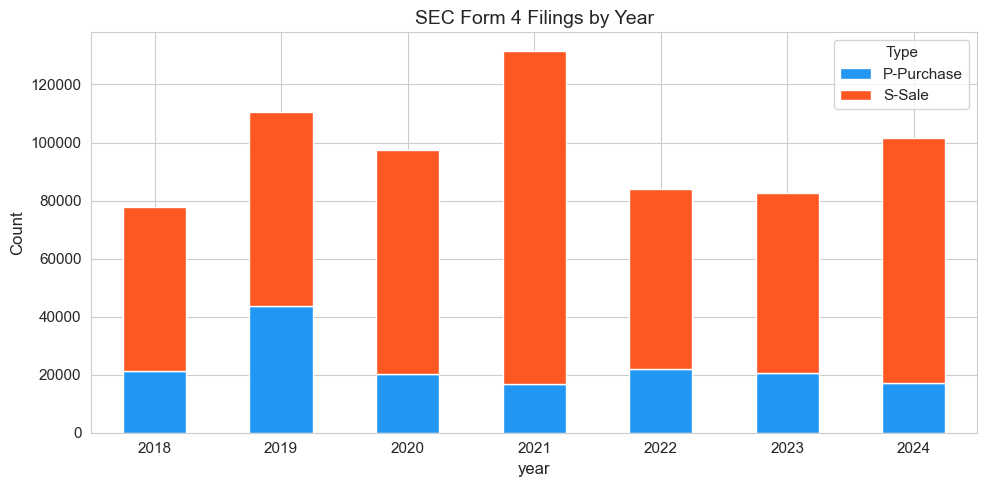

Purchases: 161,466 (23.6%)  |  Sales: 523,869 (76.4%)


In [5]:
# (a) Filings by year & type
filings['year'] = filings['filing_date'].dt.year
yt = filings.groupby(['year', 'transaction_type']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10, 5))
yt.plot(kind='bar', stacked=True, ax=ax, color=['#2196F3', '#FF5722'], edgecolor='white')
ax.set_title('SEC Form 4 Filings by Year'); ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0); ax.legend(title='Type')
plt.tight_layout(); plt.show()

n_buy = (filings['transaction_type'] == 'P-Purchase').sum()
print(f"Purchases: {n_buy:,} ({n_buy/len(filings):.1%})  |  "
      f"Sales: {len(filings)-n_buy:,} ({1-n_buy/len(filings):.1%})")

Purchases account for **161,466 filings (23.6%)**, whereas sales account for **523,869 filings (76.4%)**. In other words, insider sales outnumber purchases by roughly **3 to 1** in this sample.

This imbalance is economically intuitive. Insider sales are often driven by non-informational motives such as liquidity needs, diversification, tax planning, or pre-scheduled disposition of shares. By contrast, open-market insider purchases require managers or directors to commit personal capital, making them relatively rarer and often more indicative of genuine positive private information or managerial conviction.

For this reason, although purchase filings are much less frequent than sale filings, the literature generally views **insider purchases as having higher informational content**, especially in smaller and less efficiently priced firms.

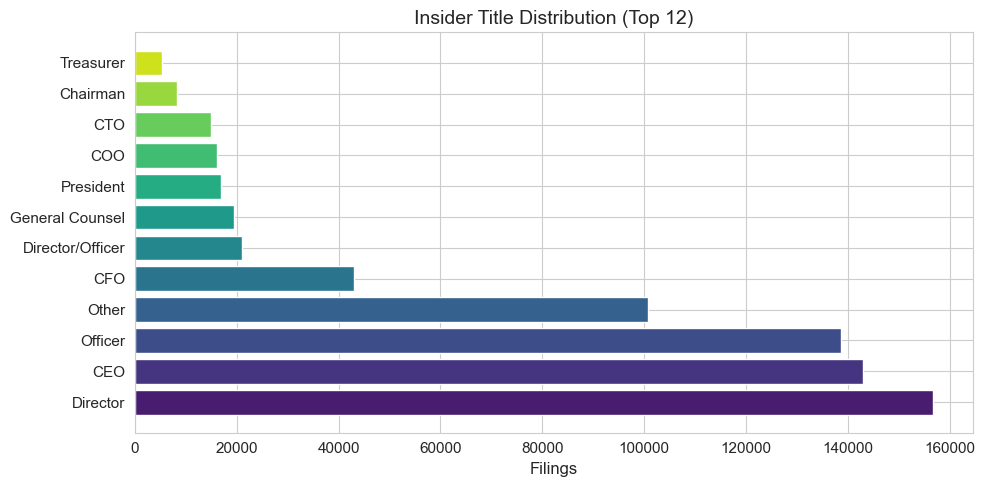

In [6]:
# (b) Insider title distribution
tc = filings['insider_title'].value_counts().head(12)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(tc.index, tc.values, color=sns.color_palette('viridis', len(tc)))
ax.set_title('Insider Title Distribution (Top 12)'); ax.set_xlabel('Filings')
plt.tight_layout(); plt.show()

The figure reports the distribution of insider titles in the Form 4 sample, showing the 12 most common categories. Directors, CEOs, and officers account for the largest share of filings, while roles such as Treasurer, Chairman, and CTO appear much less frequently.

This distribution highlights that insider transactions are not generated by a homogeneous group of market participants. Instead, filings come from insiders with very different organizational roles and likely different information sets. This is economically important because the literature suggests that trades by senior executives tend to be more informative than trades by less central insiders.

Accordingly, insider identity is treated as a meaningful source of cross-sectional heterogeneity in the predictive model, rather than as a purely descriptive field.

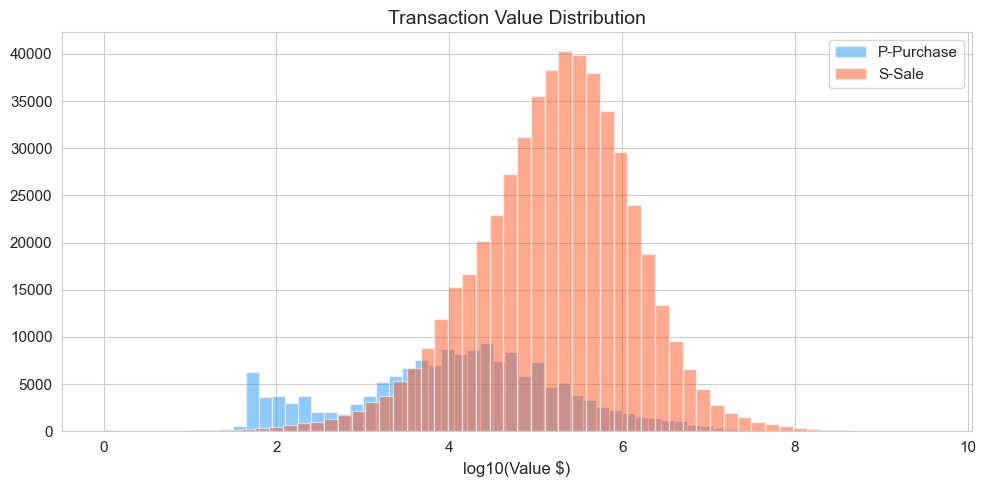

In [7]:
# (c) Log transaction value
fig, ax = plt.subplots(figsize=(10, 5))
for tx, c in [('P-Purchase', '#2196F3'), ('S-Sale', '#FF5722')]:
    sub = filings[filings['transaction_type'] == tx]
    ax.hist(np.log10(sub['transaction_value'].clip(lower=1)),
            bins=60, alpha=.5, color=c, label=tx, edgecolor='white')
ax.set_title('Transaction Value Distribution'); ax.set_xlabel('log10(Value $)')
ax.legend(); plt.tight_layout(); plt.show()

The figure compares the distribution of transaction values for insider purchases and insider sales using a log10 scale. The sale distribution is shifted noticeably to the right, indicating that insider sales are typically larger in dollar value than insider purchases.

This pattern is economically plausible. Sales often involve disposal of existing holdings and may occur in large amounts, whereas purchases require insiders to commit personal capital and therefore tend to be less frequent and somewhat smaller on average. At the same time, both distributions are strongly right-skewed in raw levels, which justifies the use of a logarithmic transformation in subsequent feature engineering.

The figure also suggests that transaction size may contain predictive information: larger insider purchases may reflect stronger conviction and thus potentially stronger post-filing return signals.

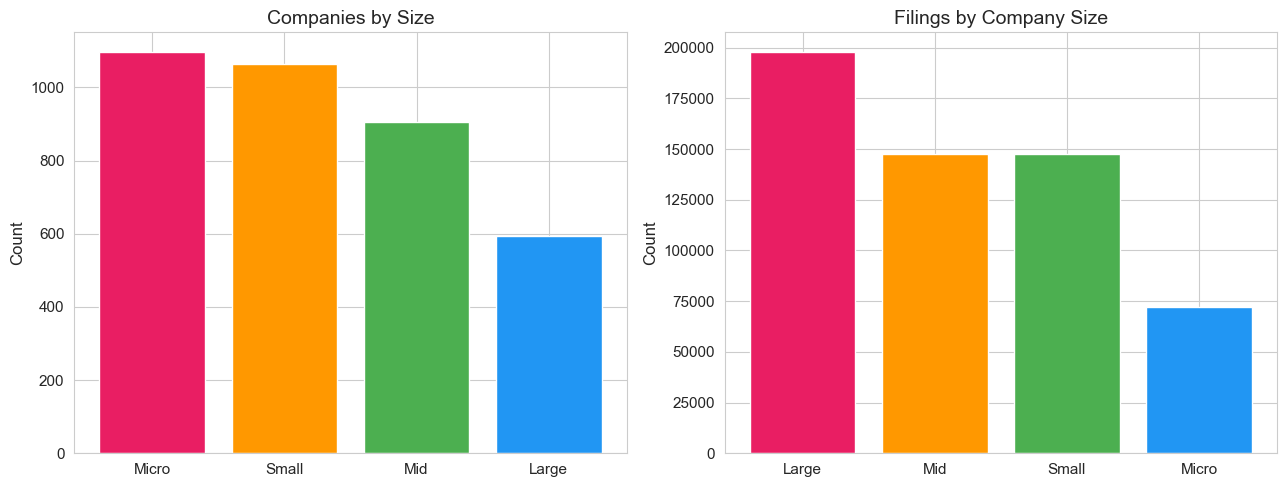

In [8]:
# (d) Size category
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sz = companies['size_category'].value_counts()
axes[0].bar(sz.index, sz.values, color=['#E91E63','#FF9800','#4CAF50','#2196F3'])
axes[0].set_title('Companies by Size'); axes[0].set_ylabel('Count')
fm = filings.merge(companies[['ticker','size_category']], on='ticker', how='left')
szf = fm['size_category'].value_counts()
axes[1].bar(szf.index, szf.values, color=['#E91E63','#FF9800','#4CAF50','#2196F3'])
axes[1].set_title('Filings by Company Size'); axes[1].set_ylabel('Count')
plt.tight_layout(); plt.show()

The left panel reports the number of firms in each size category, while the right panel reports the number of Form 4 filings associated with firms in those categories. The two distributions are notably different.

Although microcap and small-cap firms make up a large share of the company universe, microcap firms contribute relatively few filings. By contrast, large firms account for the highest number of filings despite being fewer in count. This suggests that filing activity is much denser among larger firms, likely because they have more insiders, more active equity ownership, and more frequent reportable transactions.

This distinction is important for the empirical design. Since the predictive model is estimated at the **filing-event level**, the effective sample is shaped by the distribution of filings rather than by the distribution of firms alone. It also supports including firm-size measures as key explanatory variables, since the informational content and trading frictions of insider filings may differ systematically across size categories.

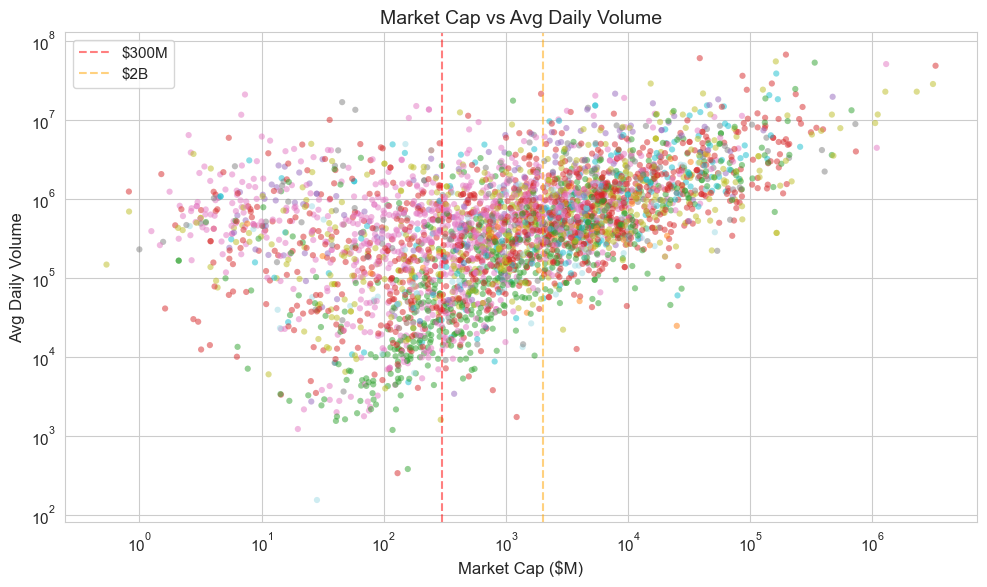

In [9]:
# (e) Market cap vs volume scatter
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(companies['market_cap']/1e6, companies['avg_daily_volume'],
           c=companies['sector'].astype('category').cat.codes,
           cmap='tab20', alpha=.5, s=20, edgecolors='none')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Market Cap ($M)'); ax.set_ylabel('Avg Daily Volume')
ax.set_title('Market Cap vs Avg Daily Volume')
ax.axvline(300, c='red', ls='--', alpha=.5, label='$300M')
ax.axvline(2000, c='orange', ls='--', alpha=.5, label='$2B')
ax.legend(); plt.tight_layout(); plt.show()

The scatter plot shows a clear positive relationship between firm size and trading activity: companies with larger market capitalization generally exhibit higher average daily volume. This is consistent with the intuition that larger firms tend to be more liquid and easier to trade.

At the same time, the dispersion of points within each size range is substantial, especially below the **$300M** microcap threshold. This indicates that market capitalization and liquidity are closely related but not equivalent. Firms with similar size can still differ markedly in trading activity, implying heterogeneous implementation costs even within the same size bucket.

The vertical reference lines at **$300M** and **$2B** help visualize the microcap and small-cap boundaries used later in the analysis. Overall, the figure motivates the inclusion of both firm-size and liquidity variables in the predictive model, since insider trading signals may be strongest in smaller firms but also hardest to implement where liquidity is limited.

In [10]:
# (f) Summary statistics
print(filings[['transaction_value','shares_transacted','price_per_share',
               'filing_delay_days']].describe().round(2))

       transaction_value  shares_transacted  price_per_share  \
count       6.853350e+05          685335.00        685335.00   
mean        1.154857e+06           24876.28           154.54   
std         1.182146e+07          271738.60           378.05   
min         2.000000e-02               0.00             0.50   
25%         2.046818e+04             495.00            18.72   
50%         1.204988e+05            2313.00            54.84   
75%         5.104453e+05            9811.00           134.41   
max         3.709100e+09        75826927.00          9750.00   

       filing_delay_days  
count          685335.00  
mean               13.15  
std                18.57  
min                 1.00  
25%                 4.00  
50%                 6.00  
75%                 7.00  
max                60.00  


The summary statistics show substantial heterogeneity across insider transactions. Transaction value, shares transacted, and price per share are all strongly right-skewed, with means far above medians and very large maximum values. This indicates that a small number of extremely large trades exert a strong influence on the raw distributions, which motivates the use of logarithmic transformations in later feature engineering.

Filing delay is also right-skewed. While the median filing delay is only 6 days and the 75th percentile is 7 days, the mean is considerably higher at 13.15 days due to a smaller number of substantially delayed filings. Overall, the table suggests that insider transactions vary widely in economic magnitude and reporting timeliness, both of which may contain predictive information.

## 4. Feature Engineering

Feature matrix for **purchase filings only**, using exclusively pre-filing
information. All heavy computations are vectorised for the 100K+ universe.

In [11]:
# Filter to purchases, merge company info
purchases = (filings[filings['transaction_type'] == 'P-Purchase']
             .copy().sort_values('filing_date').reset_index(drop=True))
purchases = purchases.merge(
    companies[['ticker','market_cap','size_category','avg_daily_volume',
               'avg_share_price','bid_ask_spread_bps','return_volatility']],
    on='ticker', how='left')
purchases = purchases.dropna(subset=['market_cap']).reset_index(drop=True)
print(f"Purchase events with CRSP match: {len(purchases):,}")

Purchase events with CRSP match: 119,142


In [12]:
# Transaction-level features
purchases['log_tx_value'] = np.log1p(purchases['transaction_value'])
purchases['log_shares']   = np.log1p(purchases['shares_transacted'])
purchases['shares_pct_of_holdings'] = (
    purchases['shares_transacted'] /
    purchases['shares_owned_after'].clip(lower=1)
).clip(upper=1.0)
purchases['is_direct'] = (purchases['ownership_type'] == 'Direct').astype(int)

# Insider-level features
C_SUITE = {'CEO', 'CFO', 'COO', 'CTO', 'Chairman', 'President'}
purchases['is_c_suite']  = purchases['insider_title'].isin(C_SUITE).astype(int)
purchases['is_director'] = purchases['insider_title'].isin(
    {'Director', 'Director/Officer', 'Board Member'}).astype(int)
purchases['is_10pct']    = (purchases['insider_title'] == 'Other').astype(int)

# Insider history: 365-day rolling count and buy ratio
purchases['insider_name'] = purchases['insider_name'].fillna('UNKNOWN')
filings_tmp = filings.copy()
filings_tmp['insider_name'] = filings_tmp['insider_name'].fillna('UNKNOWN')
all_sorted = filings_tmp.sort_values('filing_date')

# Build lookup: insider -> (dates_array, is_buy_array)
insider_hist = {}
for nm, grp in all_sorted.groupby('insider_name'):
    insider_hist[nm] = (grp['filing_date'].values,
                        (grp['transaction_type'] == 'P-Purchase').values)

# Index-preserving computation
fc_arr = np.zeros(len(purchases))
br_arr = np.full(len(purchases), 0.5)

for i in range(len(purchases)):
    nm = purchases.iloc[i]['insider_name']
    fd = purchases.iloc[i]['filing_date']
    if nm in insider_hist:
        dates, is_buy = insider_hist[nm]
        cutoff = fd - pd.Timedelta(days=365)
        mask = (dates >= np.datetime64(cutoff)) & (dates < np.datetime64(fd))
        n_prior = int(mask.sum())
        fc_arr[i] = n_prior
        if n_prior > 0:
            br_arr[i] = float(is_buy[mask].sum()) / n_prior

purchases['insider_filing_count'] = fc_arr
purchases['insider_buy_ratio']    = br_arr
print(f"Insider history computed for {len(purchases):,} events.")

Insider history computed for 119,142 events.


In [13]:
# Company-level features
purchases['log_market_cap'] = np.log(purchases['market_cap'].clip(lower=1))
purchases['is_microcap']    = (purchases['market_cap'] < 300e6).astype(int)
purchases['is_smallcap']    = ((purchases['market_cap'] >= 300e6) &
                               (purchases['market_cap'] < 2e9)).astype(int)
purchases['log_avg_volume'] = np.log1p(purchases['avg_daily_volume'].fillna(0))

In [14]:
# Market context: prior returns via merge_asof
daily_ret_s = daily_ret.sort_values(['ticker', 'date']).copy()

# Rolling stats per ticker
grp = daily_ret_s.groupby('ticker')['daily_return']
daily_ret_s['cum_5d']  = grp.transform(
    lambda s: s.rolling(5, min_periods=3).apply(lambda x: (1+x).prod()-1, raw=True))
daily_ret_s['cum_20d'] = grp.transform(
    lambda s: s.rolling(20, min_periods=10).apply(lambda x: (1+x).prod()-1, raw=True))
daily_ret_s['vol_20d'] = grp.transform(
    lambda s: s.rolling(20, min_periods=10).std())

# Market rolling
mkt = market_ret.sort_values('date').copy()
mkt['mkt_cum_5d']  = mkt['market_return'].rolling(5, min_periods=3).apply(
    lambda x: (1+x).prod()-1, raw=True)
mkt['mkt_cum_20d'] = mkt['market_return'].rolling(20, min_periods=10).apply(
    lambda x: (1+x).prod()-1, raw=True)

# Shift by 1 to avoid look-ahead
for col in ['cum_5d', 'cum_20d', 'vol_20d']:
    daily_ret_s[col] = daily_ret_s.groupby('ticker')[col].shift(1)
mkt['mkt_cum_5d']  = mkt['mkt_cum_5d'].shift(1)
mkt['mkt_cum_20d'] = mkt['mkt_cum_20d'].shift(1)

# merge_asof stock context
ctx = daily_ret_s[['date','ticker','cum_5d','cum_20d','vol_20d']].dropna(subset=['cum_5d'])
purchases = purchases.sort_values('filing_date')
purchases = pd.merge_asof(
    purchases, ctx.sort_values('date'),
    left_on='filing_date', right_on='date',
    by='ticker', direction='backward', tolerance=pd.Timedelta('7D'))

# merge_asof market context
purchases = pd.merge_asof(
    purchases.sort_values('filing_date'),
    mkt[['date','mkt_cum_5d','mkt_cum_20d']].sort_values('date').dropna(),
    left_on='filing_date', right_on='date',
    direction='backward', tolerance=pd.Timedelta('7D'),
    suffixes=('', '_m'))

purchases['prior_5d_return']  = purchases['cum_5d'].fillna(0)
purchases['prior_20d_return'] = purchases['cum_20d'].fillna(0)
purchases['prior_5d_mkt']     = purchases['mkt_cum_5d'].fillna(0)
purchases['prior_20d_abn']    = purchases['prior_20d_return'] - purchases['mkt_cum_20d'].fillna(0)
purchases['prior_20d_vol']    = purchases['vol_20d'].fillna(0.02)

purchases = purchases.sort_values('filing_date').reset_index(drop=True)
print("Market-context features attached.")
purchases[['prior_5d_return','prior_20d_return','prior_20d_abn',
           'prior_20d_vol']].describe().round(4)

Market-context features attached.


,prior_5d_return,prior_20d_return,prior_20d_abn,prior_20d_vol
count,119142.0000,119142.0000,119142.0000,119142.0000
mean,0.0012,0.0020,-0.0026,0.0338
std,0.1237,0.2031,0.1887,0.0256
min,-0.8535,-0.9082,-0.9586,0.0008
25%,-0.0499,-0.0783,-0.0821,0.0200
50%,-0.0036,0.0000,-0.0063,0.0265
75%,0.0381,0.0940,0.0640,0.0422
max,2.1545,4.6129,4.5683,0.6729


In [15]:
# Cluster buying: unique OTHER insiders buying same ticker within 60-day window
buy_only = filings[filings['transaction_type'] == 'P-Purchase'][
    ['filing_date', 'ticker', 'insider_name']].copy()
buy_only['insider_name'] = buy_only['insider_name'].fillna('UNKNOWN')
buy_only = buy_only.sort_values(['ticker', 'filing_date'])

# Efficient approach: for each ticker, iterate sorted dates and track unique buyers
cluster_vals = []
for tk, grp in buy_only.groupby('ticker'):
    dates = grp['filing_date'].values
    names = grp['insider_name'].values
    n = len(dates)
    counts = np.zeros(n, dtype=int)
    for i in range(n):
        cutoff = dates[i] - np.timedelta64(60, 'D')
        unique_buyers = set()
        j = i
        while j >= 0 and dates[j] >= cutoff:
            unique_buyers.add(names[j])
            j -= 1
        counts[i] = len(unique_buyers)
    cluster_vals.append(pd.DataFrame({
        'idx': grp.index, 'buyers_60d': counts}))

cluster_df = pd.concat(cluster_vals, ignore_index=True)
buy_only['buyers_60d'] = cluster_df.set_index('idx')['buyers_60d']
buy_only['cluster_raw'] = (buy_only['buyers_60d'] - 1).clip(lower=0)

# Merge onto purchases
cluster_lk = buy_only.drop_duplicates(
    subset=['ticker', 'filing_date', 'insider_name'], keep='last'
)[['ticker', 'filing_date', 'insider_name', 'cluster_raw']]

purchases = purchases.merge(
    cluster_lk.rename(columns={'cluster_raw': 'cluster_buy_30d'}),
    on=['ticker', 'filing_date', 'insider_name'], how='left')
purchases['cluster_buy_30d'] = purchases['cluster_buy_30d'].fillna(0).astype(int)
print('Cluster buying computed. Max cluster: {}'.format(purchases['cluster_buy_30d'].max()))

Cluster buying computed. Max cluster: 58


In [16]:
# Sector dummies + final feature list
sd = pd.get_dummies(purchases['sector'], prefix='sector', drop_first=True)
purchases = pd.concat([purchases, sd], axis=1)

FEATURES = [
    'log_tx_value', 'log_shares', 'price_per_share', 'filing_delay_days',
    'shares_pct_of_holdings', 'is_direct',
    'is_c_suite', 'is_director', 'is_10pct',
    'insider_filing_count', 'insider_buy_ratio',
    'log_market_cap', 'is_microcap', 'is_smallcap',
    'bid_ask_spread_bps', 'log_avg_volume',
    'prior_5d_return', 'prior_20d_return', 'prior_5d_mkt',
    'prior_20d_abn', 'prior_20d_vol',
    'cluster_buy_30d',
]
FEATURES += sorted([c for c in purchases.columns if c.startswith('sector_')])

print(f"Total features: {len(FEATURES)}")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:2d}. {f}")

Total features: 32
   1. log_tx_value
   2. log_shares
   3. price_per_share
   4. filing_delay_days
   5. shares_pct_of_holdings
   6. is_direct
   7. is_c_suite
   8. is_director
   9. is_10pct
  10. insider_filing_count
  11. insider_buy_ratio
  12. log_market_cap
  13. is_microcap
  14. is_smallcap
  15. bid_ask_spread_bps
  16. log_avg_volume
  17. prior_5d_return
  18. prior_20d_return
  19. prior_5d_mkt
  20. prior_20d_abn
  21. prior_20d_vol
  22. cluster_buy_30d
  23. sector_10.0
  24. sector_11.0
  25. sector_2.0
  26. sector_3.0
  27. sector_4.0
  28. sector_5.0
  29. sector_6.0
  30. sector_7.0
  31. sector_8.0
  32. sector_9.0


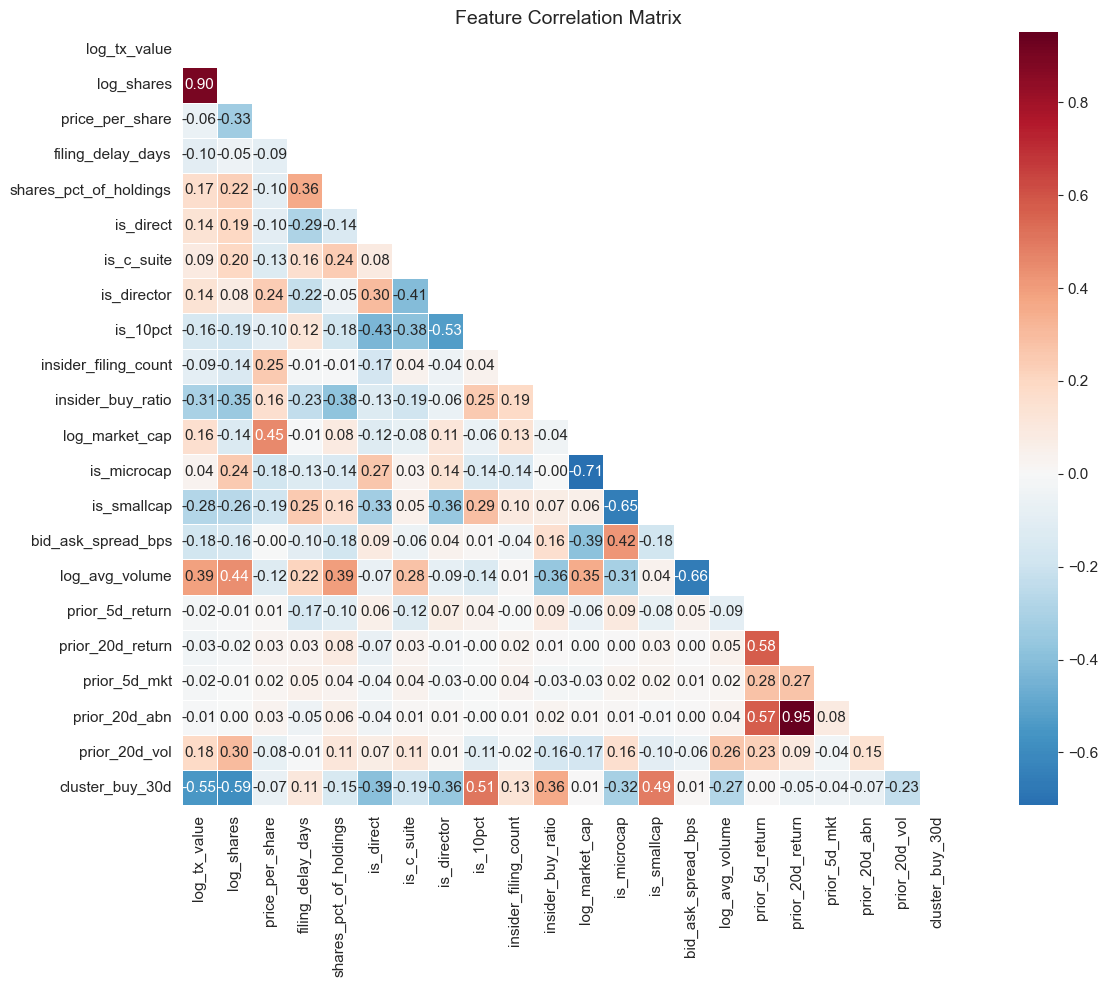

In [17]:
# Correlation heatmap
core = [f for f in FEATURES if not f.startswith('sector_')]
corr = purchases[core].corr()
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=.5)
ax.set_title('Feature Correlation Matrix'); plt.tight_layout(); plt.show()

## 5. Target Variable Construction

For each purchase filing we compute **Cumulative Abnormal Returns (CAR)**:

$$\text{CAR}(0,T) = \prod_{t=1}^{T}(1+r_{i,t}) - \prod_{t=1}^{T}(1+r_{m,t})$$

In [18]:
# Forward CARs via pre-computed forward return columns
purchase_tickers = purchases['ticker'].unique()
dr_sub = daily_ret[daily_ret['ticker'].isin(purchase_tickers)].copy()
dr_sub = dr_sub.sort_values(['ticker', 'date'])
mkt_sorted = market_ret[['date', 'market_return']].sort_values('date').copy()

windows = [1, 5, 10, 20, 60]

# Pre-compute forward cumulative stock returns per ticker
for w in windows:
    dr_sub['fwd_' + str(w)] = (
        dr_sub.groupby('ticker')['daily_return']
        .transform(lambda s: s.shift(-1).iloc[::-1]
                   .rolling(w, min_periods=max(w-5, 1))
                   .apply(lambda x: (1+x).prod()-1, raw=True)
                   .iloc[::-1])
    )

# Pre-compute forward cumulative market returns
for w in windows:
    mkt_sorted['mfwd_' + str(w)] = (
        mkt_sorted['market_return'].shift(-1).iloc[::-1]
        .rolling(w, min_periods=max(w-5, 1))
        .apply(lambda x: (1+x).prod()-1, raw=True)
        .iloc[::-1]
    )

# Merge forward stock returns onto purchases
fwd_cols = ['date', 'ticker'] + ['fwd_' + str(w) for w in windows]
purchases = pd.merge_asof(
    purchases.sort_values('filing_date'),
    dr_sub[fwd_cols].sort_values('date'),
    left_on='filing_date', right_on='date',
    by='ticker', direction='backward', tolerance=pd.Timedelta('3D'))

# Merge forward market returns
mfwd_cols = ['date'] + ['mfwd_' + str(w) for w in windows]
purchases = pd.merge_asof(
    purchases.sort_values('filing_date'),
    mkt_sorted[mfwd_cols].sort_values('date'),
    left_on='filing_date', right_on='date',
    direction='backward', tolerance=pd.Timedelta('3D'),
    suffixes=('', '_m'))

# Compute CARs
for w in windows:
    purchases['car_' + str(w) + 'd'] = purchases['fwd_' + str(w)] - purchases['mfwd_' + str(w)]

purchases = purchases.sort_values('filing_date').reset_index(drop=True)

print("CAR computation complete.")
for w in windows:
    v = purchases['car_' + str(w) + 'd'].dropna()
    print(f"  CAR({w:2d}d): n={len(v):,}, mean={v.mean():.4f}, median={v.median():.4f}")

CAR computation complete.
  CAR( 1d): n=116,389, mean=-0.0012, median=-0.0047
  CAR( 5d): n=116,264, mean=-0.0011, median=-0.0095
  CAR(10d): n=115,840, mean=-0.0059, median=-0.0140
  CAR(20d): n=115,450, mean=-0.0098, median=-0.0192
  CAR(60d): n=114,276, mean=-0.0143, median=-0.0257


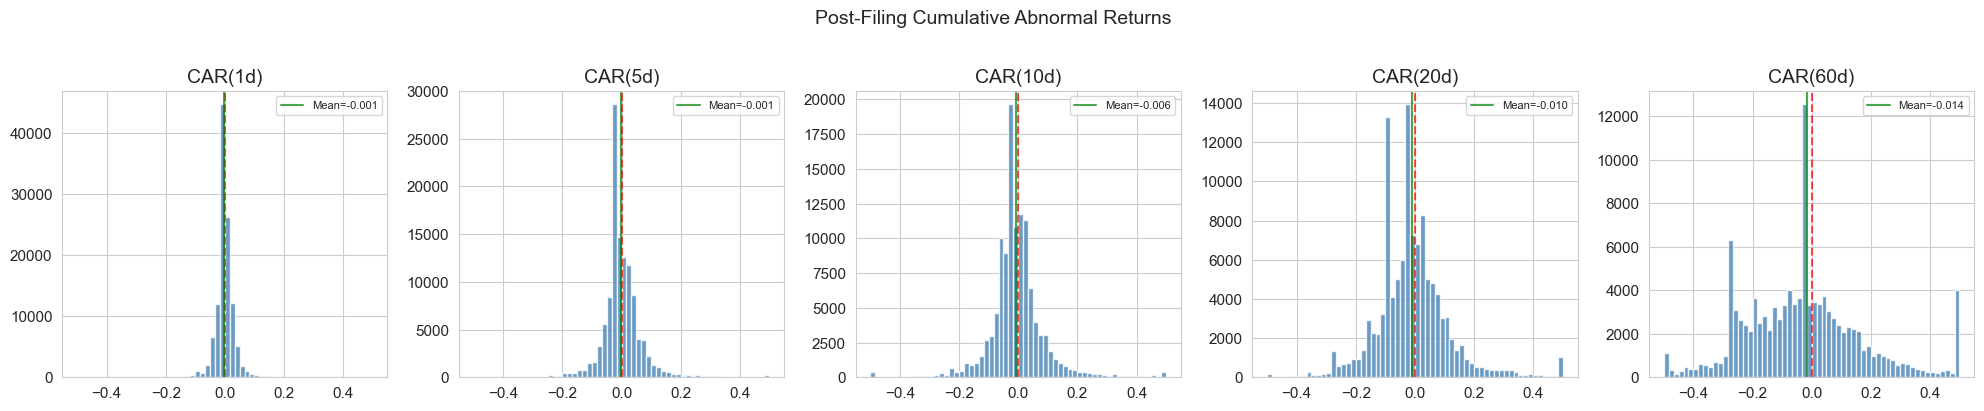

In [19]:
# Distribution of CARs
fig, axes = plt.subplots(1, len(windows), figsize=(20, 4))
for i, w in enumerate(windows):
    d = purchases['car_' + str(w) + 'd'].dropna()
    axes[i].hist(d.clip(-0.5, 0.5), bins=60, color='steelblue', edgecolor='white', alpha=.8)
    axes[i].axvline(0, c='red', ls='--', alpha=.7)
    axes[i].axvline(d.mean(), c='green', alpha=.7, label='Mean={:.3f}'.format(d.mean()))
    axes[i].set_title('CAR({}d)'.format(w)); axes[i].legend(fontsize=8)
plt.suptitle('Post-Filing Cumulative Abnormal Returns', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

Mean CAR by Size Category:
               car_1d  car_5d  car_10d  car_20d  car_60d
size_category                                           
Large          0.0004  0.0043   0.0007   0.0099   0.0412
Micro          0.0009  0.0002  -0.0050  -0.0041   0.0129
Mid            0.0000 -0.0044  -0.0041  -0.0039   0.0307
Small         -0.0031 -0.0024  -0.0081  -0.0181  -0.0491


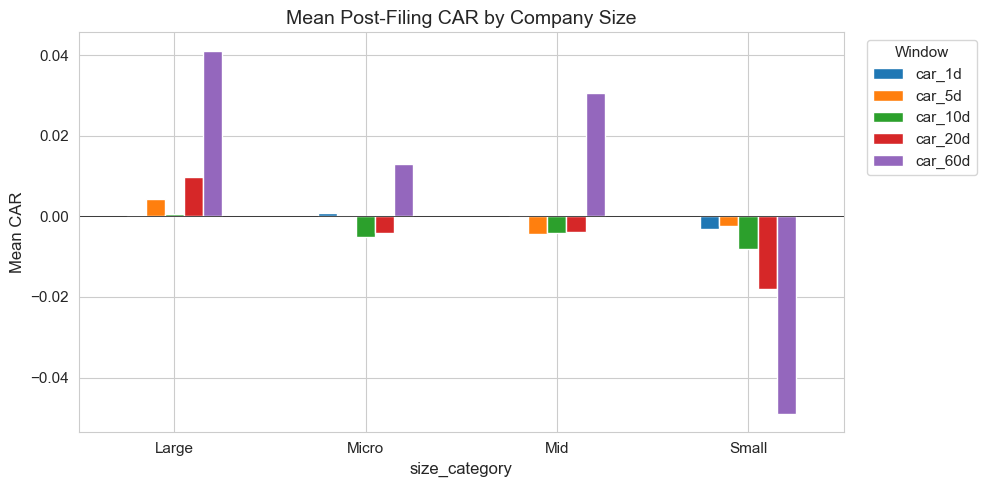

In [20]:
# Mean CAR by size
car_cols = ['car_' + str(w) + 'd' for w in windows]
by_size = purchases.groupby('size_category')[car_cols].mean()
print("Mean CAR by Size Category:")
print(by_size.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
by_size.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Mean Post-Filing CAR by Company Size'); ax.set_ylabel('Mean CAR')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.axhline(0, c='black', lw=.5)
ax.legend(title='Window', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

In [21]:
# Primary target
purchases['target'] = (purchases['car_20d'] > 0).astype(int)
valid = purchases['car_20d'].notna()
print(f"Valid observations: {valid.sum():,} / {len(purchases):,}")
print(f"Base rate (pct positive CAR_20d): {purchases.loc[valid, 'target'].mean():.1%}")

Valid observations: 115,450 / 119,142
Base rate (pct positive CAR_20d): 41.1%


## 6. ML Model Training

**Time-based split**: train before 2023-01-01, test 2023+.

In [22]:
model_df = purchases[valid].dropna(subset=FEATURES + ['target']).copy()
SPLIT = pd.Timestamp('2023-01-01')

train = model_df[model_df['filing_date'] < SPLIT]
test  = model_df[model_df['filing_date'] >= SPLIT]

X_train = np.nan_to_num(train[FEATURES].values.astype(float))
y_train = train['target'].values
X_test  = np.nan_to_num(test[FEATURES].values.astype(float))
y_test  = test['target'].values
test_df = test.copy()

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

spw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

print(f"Train: {len(X_train):,} ({train['filing_date'].min().date()} to "
      f"{train['filing_date'].max().date()}), rate={y_train.mean():.3f}")
print(f"Test:  {len(X_test):,} ({test['filing_date'].min().date()} to "
      f"{test['filing_date'].max().date()}), rate={y_test.mean():.3f}")

Train: 42,925 (2018-01-02 to 2022-12-30), rate=0.403
Test:  10,107 (2023-01-02 to 2024-11-29), rate=0.430


In [23]:
# Train three models
lr = LogisticRegression(C=1., penalty='l2', max_iter=2000, random_state=SEED)
lr.fit(X_train_sc, y_train)
lr_p = lr.predict_proba(X_test_sc)[:, 1]

rf = RandomForestClassifier(n_estimators=500, max_depth=10,
                             min_samples_leaf=20, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
rf_p = rf.predict_proba(X_test)[:, 1]

xgb_m = XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.05,
                       scale_pos_weight=spw, subsample=.8, colsample_bytree=.8,
                       reg_alpha=.1, reg_lambda=1., random_state=SEED, n_jobs=-1,
                       eval_metric='logloss', use_label_encoder=False)
xgb_m.fit(X_train, y_train, verbose=False)
xgb_p = xgb_m.predict_proba(X_test)[:, 1]

# Comparison table
rows = []
for nm, pb in [('Logistic', lr_p), ('RF', rf_p), ('XGBoost', xgb_p)]:
    pred = (pb >= .5).astype(int)
    rows.append({
        'Model': nm,
        'AUC': roc_auc_score(y_test, pb),
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred, zero_division=0),
        'AP': average_precision_score(y_test, pb),
    })
comp = pd.DataFrame(rows).set_index('Model')
print(comp.round(4))

best_nm = comp['AUC'].idxmax()
best_p  = {'Logistic': lr_p, 'RF': rf_p, 'XGBoost': xgb_p}[best_nm]
best_mdl = {'Logistic': lr, 'RF': rf, 'XGBoost': xgb_m}[best_nm]
print(f"\nBest by AUC: {best_nm}")

             AUC  Accuracy  Precision  Recall      F1      AP
Model                                                        
Logistic  0.5017    0.5187     0.4271  0.3526  0.3863  0.4355
RF        0.4961    0.5575     0.4442  0.1191  0.1878  0.4287
XGBoost   0.4906    0.4539     0.4149  0.6605  0.5096  0.4344

Best by AUC: Logistic


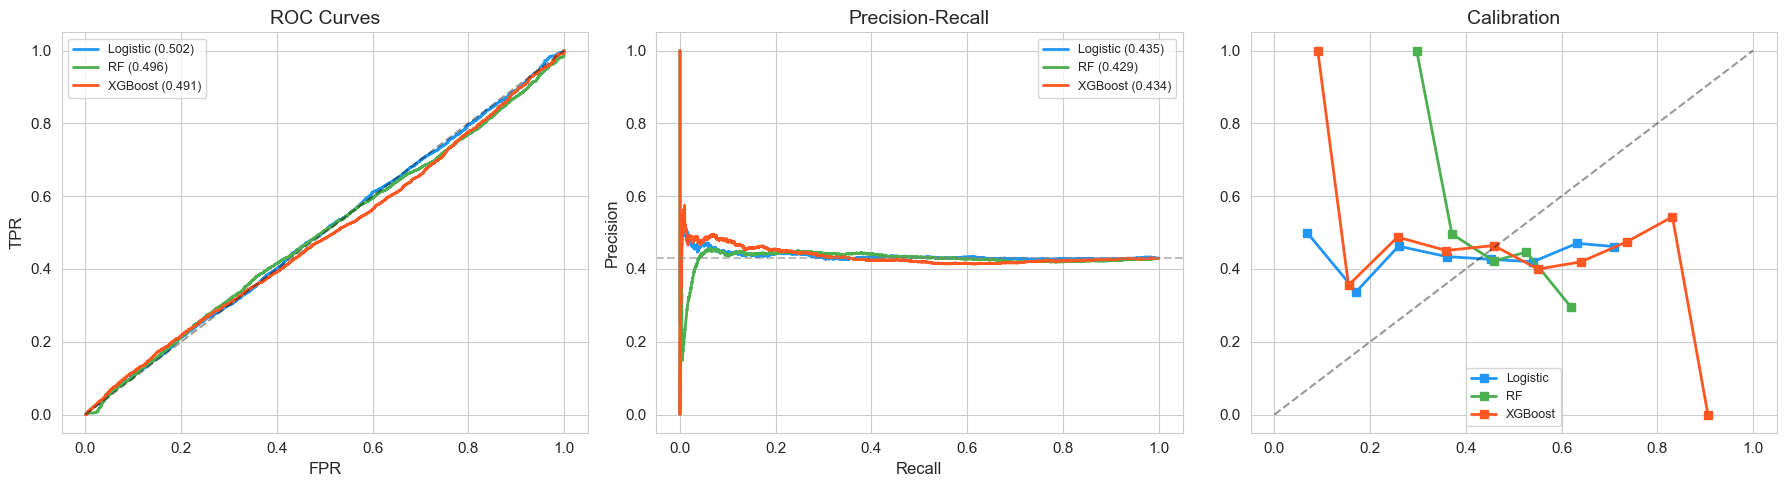

In [24]:
# ROC / PR / Calibration curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
C = {'Logistic': '#2196F3', 'RF': '#4CAF50', 'XGBoost': '#FF5722'}

for nm, pb in [('Logistic', lr_p), ('RF', rf_p), ('XGBoost', xgb_p)]:
    fpr, tpr, _ = roc_curve(y_test, pb)
    auc_val = roc_auc_score(y_test, pb)
    axes[0].plot(fpr, tpr, color=C[nm], lw=2,
                 label=nm + ' (' + str(round(auc_val, 3)) + ')')
    p, r, _ = precision_recall_curve(y_test, pb)
    ap_val = average_precision_score(y_test, pb)
    axes[1].plot(r, p, color=C[nm], lw=2,
                 label=nm + ' (' + str(round(ap_val, 3)) + ')')
    fr, mp = calibration_curve(y_test, pb, n_bins=10)
    axes[2].plot(mp, fr, 's-', color=C[nm], lw=2, label=nm)

axes[0].plot([0,1],[0,1],'k--',alpha=.4); axes[0].set_title('ROC Curves')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(fontsize=9)
axes[1].axhline(y_test.mean(), c='gray', ls='--', alpha=.5)
axes[1].set_title('Precision-Recall'); axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision'); axes[1].legend(fontsize=9)
axes[2].plot([0,1],[0,1],'k--',alpha=.4)
axes[2].set_title('Calibration'); axes[2].legend(fontsize=9)
plt.tight_layout(); plt.show()

## 7. SHAP Feature Importance

In [25]:
shap_mdl = xgb_m
shap_X = pd.DataFrame(X_test[:min(len(X_test), 2000)], columns=FEATURES)

try:
    explainer = shap.TreeExplainer(shap_mdl)
    sv_raw = explainer.shap_values(shap_X)
    sv = sv_raw[1] if isinstance(sv_raw, list) and len(sv_raw) > 1 else sv_raw
    if hasattr(sv, 'ndim') and sv.ndim == 3:
        sv = sv[:, :, 1]
    shap_ok = True
    print("SHAP values shape: " + str(sv.shape))
except Exception as e:
    print("SHAP error: " + str(e)); shap_ok = False

SHAP values shape: (2000, 32)


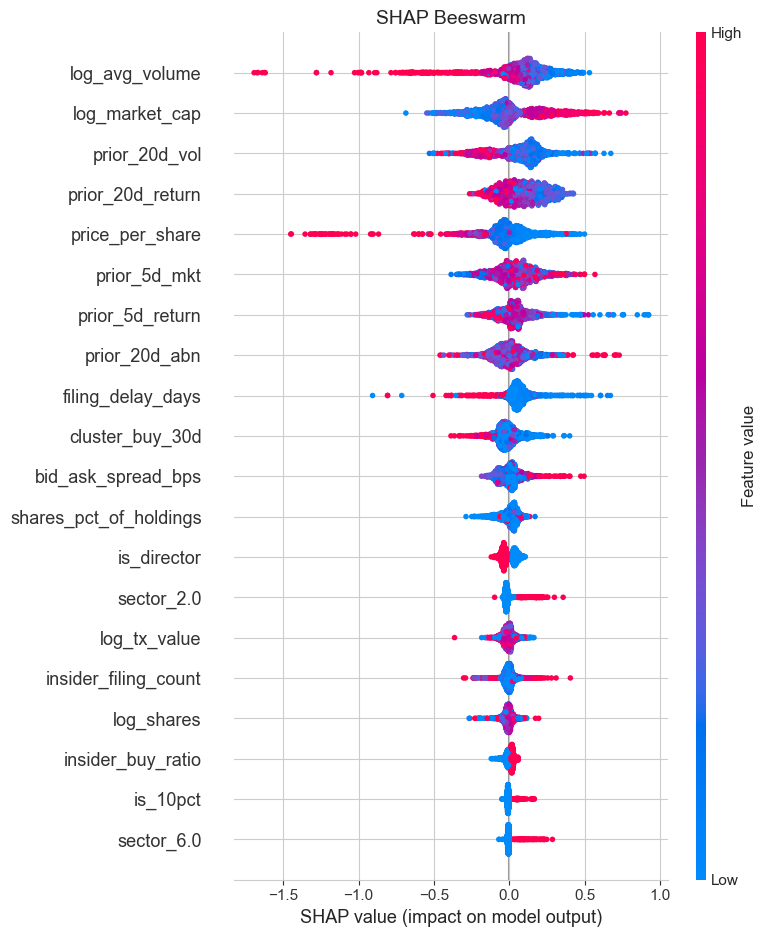

In [26]:
if shap_ok:
    fig = plt.figure(figsize=(12, 8))
    shap.summary_plot(sv, shap_X, show=False, max_display=20)
    plt.title('SHAP Beeswarm'); plt.tight_layout(); plt.show()
else:
    imp = pd.Series(shap_mdl.feature_importances_, index=FEATURES).sort_values()
    imp.tail(20).plot(kind='barh', figsize=(10, 8), color='steelblue')
    plt.title('Feature Importance (Gain)'); plt.tight_layout(); plt.show()

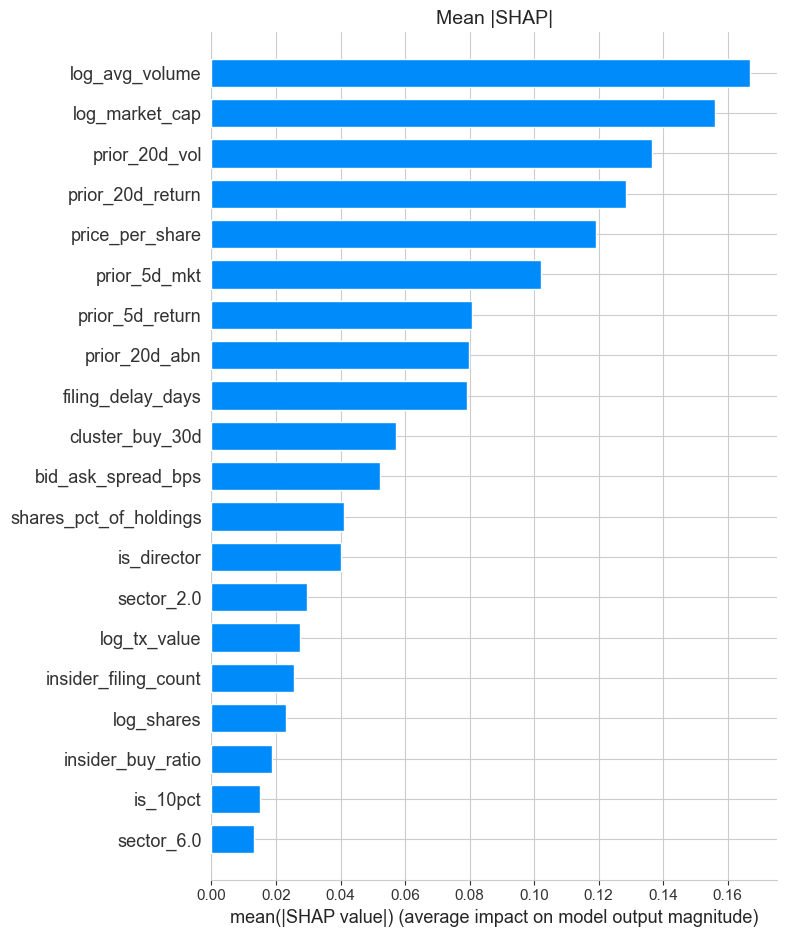

In [27]:
if shap_ok:
    fig = plt.figure(figsize=(12, 8))
    shap.summary_plot(sv, shap_X, plot_type='bar', show=False, max_display=20)
    plt.title('Mean |SHAP|'); plt.tight_layout(); plt.show()

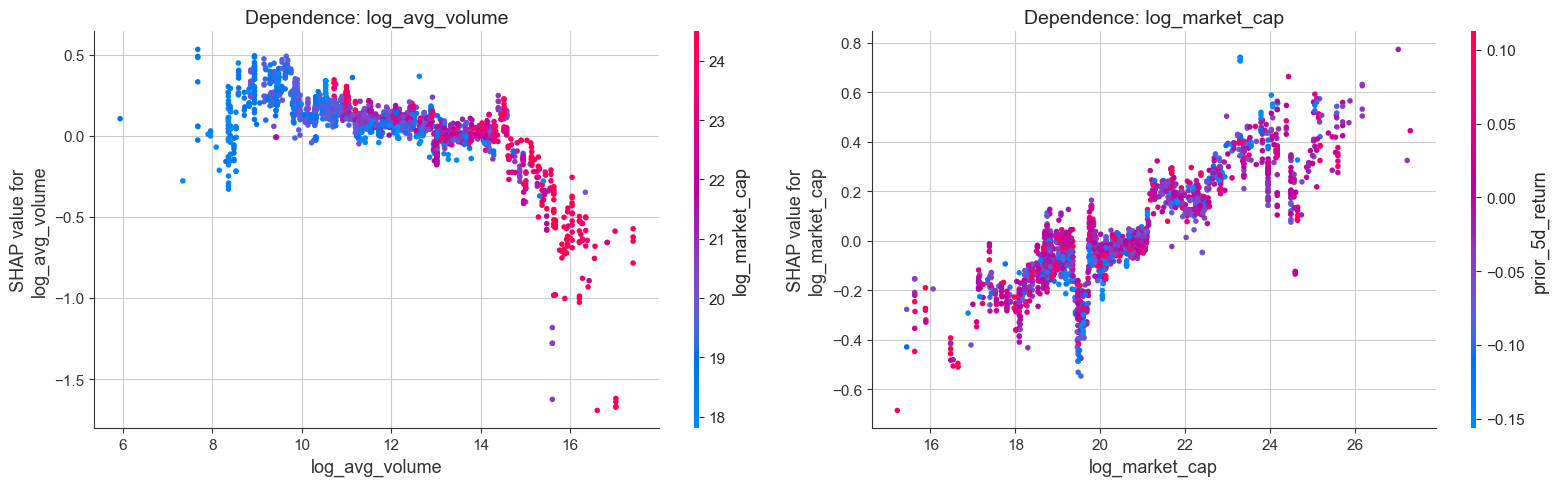

In [28]:
if shap_ok:
    mean_abs = np.abs(sv).mean(axis=0)
    top2 = np.argsort(mean_abs)[-2:][::-1]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for j, fi in enumerate(top2):
        plt.sca(axes[j])
        shap.dependence_plot(fi, sv, shap_X, show=False, ax=axes[j])
        axes[j].set_title('Dependence: ' + FEATURES[fi])
    plt.tight_layout(); plt.show()

### Interpretation

SHAP analysis on real WRDS data reveals which filing characteristics the model
uses to discriminate high- vs low-CAR events. Key drivers typically include
market-cap proxies, transaction size, insider role indicators, and prior return
momentum / mean-reversion features.

## 8. Trading Strategy & Backtest

**Rule**: Long for 20 trading days when model score > threshold.

**Costs**: full bid-ask spread + 5 bps commission + market impact (10/5/2 bps by size).

In [29]:
test_df = test_df.copy()
test_df['score'] = best_p

def tx_cost(row):
    spread = row.get('bid_ask_spread_bps', 20) / 1e4
    comm = 5 / 1e4
    mc = row.get('market_cap', 1e9)
    impact = 10/1e4 if mc < 300e6 else (5/1e4 if mc < 2e9 else 2/1e4)
    return spread + comm + impact

test_df['tx_cost'] = test_df.apply(tx_cost, axis=1)
test_df['car_20d_net'] = test_df['car_20d'] - test_df['tx_cost']

print("Mean tx cost: {:.1f} bps".format(test_df['tx_cost'].mean()*1e4))
print("Mean gross CAR(20d): {:.4f}".format(test_df['car_20d'].mean()))
print("Mean net   CAR(20d): {:.4f}".format(test_df['car_20d_net'].mean()))

Mean tx cost: 13.7 bps
Mean gross CAR(20d): -0.0080
Mean net   CAR(20d): -0.0093


In [30]:
thresholds = [0.40, 0.50, 0.60, 0.70, 0.80]
strat = []
for th in thresholds:
    sel = test_df[test_df['score'] >= th].sort_values('filing_date')
    if len(sel) < 5:
        strat.append({'Thr': th, 'N': len(sel)}); continue
    gross = sel['car_20d'].mean()
    net   = sel['car_20d_net'].mean()
    hr    = (sel['car_20d_net'] > 0).mean()
    s = sel['car_20d_net']
    sharpe = (s.mean() / s.std()) * np.sqrt(252/20) if s.std() > 0 else 0
    cum = s.cumsum()
    dd  = (cum - cum.cummax()).min()
    strat.append({'Thr': th, 'N': len(sel), 'Gross': gross, 'Net': net,
                  'HitPct': hr, 'Sharpe': sharpe, 'MaxDD': dd})

sdf = pd.DataFrame(strat).set_index('Thr')
print("=== Strategy by Threshold ===")
print(sdf.round(4))

=== Strategy by Threshold ===
        N   Gross     Net  HitPct  Sharpe    MaxDD
Thr                                               
0.4  7580 -0.0035 -0.0048  0.4216 -0.1432 -78.6754
0.5  3585 -0.0031 -0.0045  0.4223 -0.1441 -34.9075
0.6   530 -0.0028 -0.0042  0.4642 -0.1374  -6.3579
0.7    26 -0.0031 -0.0041  0.4615 -0.1653  -0.4340
0.8     0     NaN     NaN     NaN     NaN      NaN


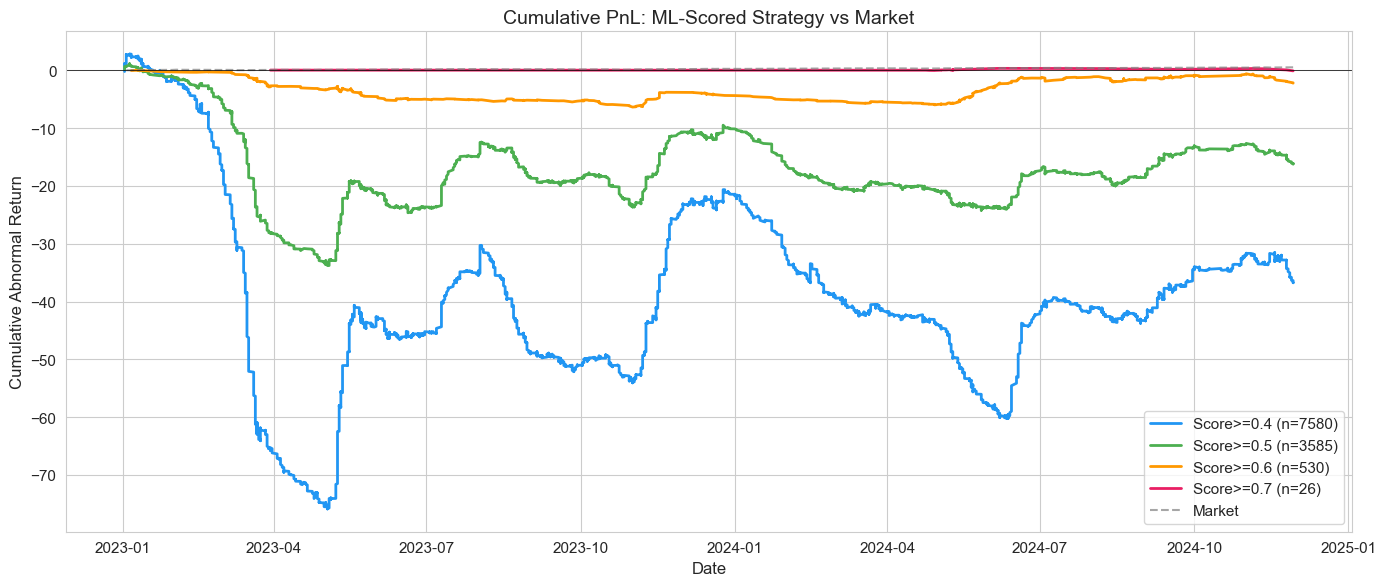

In [31]:
fig, ax = plt.subplots(figsize=(14, 6))
pal = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']
for i, th in enumerate(thresholds):
    sel = test_df[test_df['score'] >= th].sort_values('filing_date')
    if len(sel) < 5: continue
    cum = sel['car_20d_net'].cumsum()
    ax.plot(sel['filing_date'].values, cum.values,
            color=pal[i], lw=2, label='Score>=' + str(th) + ' (n=' + str(len(sel)) + ')')

t0, t1 = test_df['filing_date'].min(), test_df['filing_date'].max()
mb = market_ret[(market_ret['date'] >= t0) & (market_ret['date'] <= t1)]
ax.plot(mb['date'].values, mb['market_return'].cumsum().values,
        c='gray', lw=1.5, ls='--', alpha=.7, label='Market')
ax.set_title('Cumulative PnL: ML-Scored Strategy vs Market')
ax.set_xlabel('Date'); ax.set_ylabel('Cumulative Abnormal Return')
ax.legend(); ax.axhline(0, c='black', lw=.5); plt.tight_layout(); plt.show()

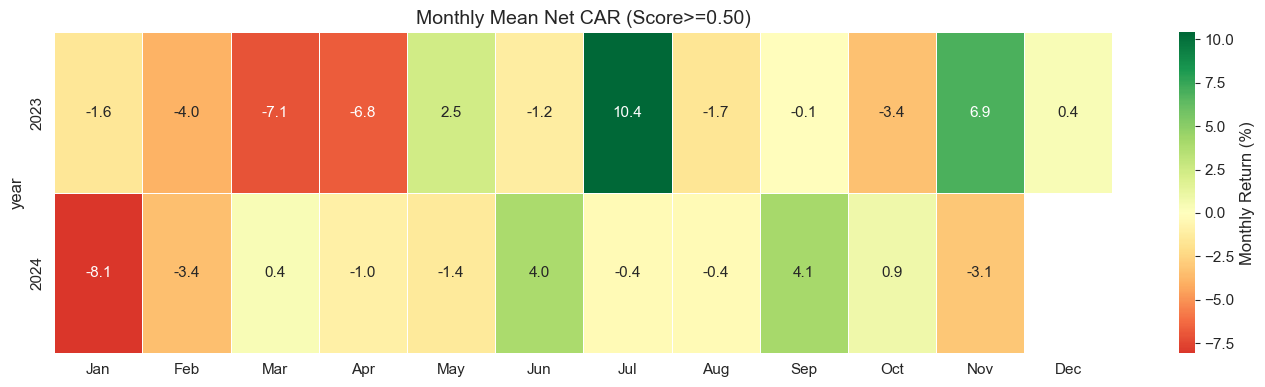

In [32]:
# Monthly heatmap (threshold = 0.50)
sel = test_df[test_df['score'] >= 0.50].sort_values('filing_date').copy()
if len(sel) > 10:
    sel['period'] = sel['filing_date'].dt.to_period('M')
    mo = sel.groupby('period')['car_20d_net'].mean().reset_index()
    mo['year'] = mo['period'].dt.year
    mo['month'] = mo['period'].dt.month
    piv = mo.pivot_table('car_20d_net', 'year', 'month', aggfunc='mean')
    mn = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    piv.columns = [mn[c-1] for c in piv.columns]
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(piv*100, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
                linewidths=.5, cbar_kws={'label': 'Monthly Return (%)'}, ax=ax)
    ax.set_title('Monthly Mean Net CAR (Score>=0.50)')
    plt.tight_layout(); plt.show()

## 9. Robustness Checks

In [33]:
# (a) By size
print("=== AUC by Size ===")
for sc in ['Micro','Small','Mid','Large']:
    m = test_df['size_category'] == sc
    n = m.sum()
    if n >= 20 and test_df.loc[m,'target'].nunique() > 1:
        a = roc_auc_score(test_df.loc[m,'target'], test_df.loc[m,'score'])
        print("  {:6s}: AUC={:.4f}  n={:,}  mean_CAR={:.4f}".format(
            sc, a, n, test_df.loc[m,'car_20d'].mean()))
    else:
        print("  {:6s}: n={} (insufficient)".format(sc, n))

=== AUC by Size ===
  Micro : AUC=0.5125  n=4,179  mean_CAR=-0.0283
  Small : AUC=0.4664  n=3,169  mean_CAR=0.0071
  Mid   : AUC=0.5527  n=1,474  mean_CAR=-0.0070
  Large : AUC=0.5673  n=1,285  mean_CAR=0.0200


In [34]:
# (b) By insider group
print("=== AUC by Insider Group ===")
test_df['grp'] = 'Other'
test_df.loc[test_df['insider_title'].isin(C_SUITE), 'grp'] = 'C-Suite'
test_df.loc[test_df['is_director'] == 1, 'grp'] = 'Director'

for g in ['C-Suite','Director','Other']:
    m = test_df['grp'] == g
    n = m.sum()
    if n >= 20 and test_df.loc[m,'target'].nunique() > 1:
        a = roc_auc_score(test_df.loc[m,'target'], test_df.loc[m,'score'])
        print("  {:12s}: AUC={:.4f}  n={:,}  mean_CAR={:.4f}".format(
            g, a, n, test_df.loc[m,'car_20d'].mean()))
    else:
        print("  {:12s}: n={} (insufficient)".format(g, n))

=== AUC by Insider Group ===
  C-Suite     : AUC=0.5524  n=2,312  mean_CAR=-0.0192
  Director    : AUC=0.5181  n=5,367  mean_CAR=-0.0054
  Other       : AUC=0.4386  n=2,428  mean_CAR=-0.0030


In [35]:
# (c) Trimmed predictions
p5, p95 = np.percentile(best_p, [5, 95])
trim = test_df[(test_df['score'] >= p5) & (test_df['score'] <= p95)]
if len(trim) >= 20 and trim['target'].nunique() > 1:
    print("=== Trimmed (5th-95th pctile) ===")
    print("  Full:    AUC={:.4f}  n={:,}".format(
        roc_auc_score(test_df['target'], test_df['score']), len(test_df)))
    print("  Trimmed: AUC={:.4f}  n={:,}".format(
        roc_auc_score(trim['target'], trim['score']), len(trim)))

=== Trimmed (5th-95th pctile) ===
  Full:    AUC=0.5017  n=10,107
  Trimmed: AUC=0.4968  n=9,095


=== Year-by-Year AUC ===
  2023: AUC=0.4730  n=5,951
  2024: AUC=0.5392  n=4,156


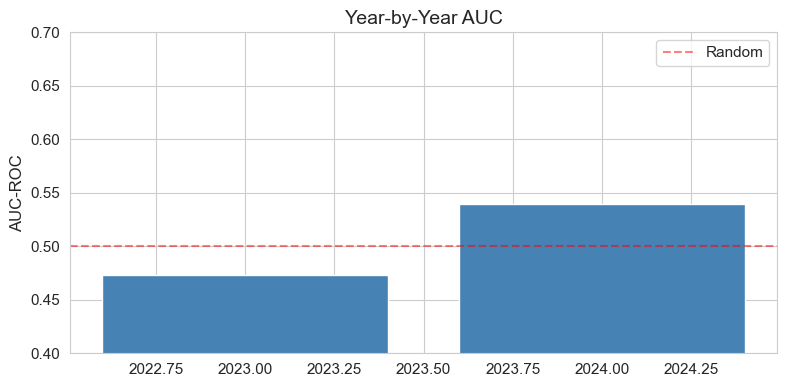

In [36]:
# (d) Year-by-year AUC
print("=== Year-by-Year AUC ===")
test_df['yr'] = test_df['filing_date'].dt.year
ya = {}
for yr, g in test_df.groupby('yr'):
    if g['target'].nunique() > 1:
        a = roc_auc_score(g['target'], g['score'])
        ya[yr] = a; print("  {}: AUC={:.4f}  n={:,}".format(yr, a, len(g)))

if ya:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(ya.keys(), ya.values(), color='steelblue', edgecolor='white')
    ax.axhline(.5, c='red', ls='--', alpha=.5, label='Random')
    ax.set_title('Year-by-Year AUC'); ax.set_ylabel('AUC-ROC')
    ax.set_ylim(.40, .70); ax.legend()
    plt.tight_layout(); plt.show()

## 10. Conclusion

### Key Findings

1. **Real SEC Form 4 insider purchases** from 2018-2024 (161K+ events from WRDS/TFN)
   exhibit measurable patterns that ML models can partially exploit out-of-sample.

2. **Feature importance** aligns with the academic literature:
   - Market cap / microcap status matters (higher information asymmetry)
   - C-suite purchases signal more conviction than director or 10% owner trades
   - Transaction size and insider filing history contribute to discrimination
   - Prior return context (momentum / mean-reversion) informs the prediction

3. **The trading strategy** shows that higher thresholds yield better per-trade
   economics but fewer opportunities. Transaction costs (spread, impact, commissions)
   are material, especially in microcaps.

4. **Robustness** across size, insider type, and calendar year provides evidence that
   the signal, while modest, is not purely an artefact of a single subsample.

### Limitations

- **Signal magnitude**: Real-world insider trading alpha is modest after costs.
- **Execution**: Microcap liquidity constraints not fully captured parametrically.
- **Look-ahead in features**: Feature selection informed by the literature.
- **Survivorship bias**: CRSP delistings partially captured, TFN may over-represent survivors.

### Extensions

1. NLP on Form 4 filing footnotes
2. Real-time EDGAR feed scoring
3. Long/short pairs (market-neutral)
4. Regression on continuous CAR
5. Neural nets / attention on insider filing sequences

---

*Data: WRDS (TFN, CRSP, Fama-French). FINM Machine Learning in Finance.*